In [3]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings

# Load the dataset

In [4]:
def parse_garmin_activity_data(json_data):
    """Parse Garmin activity JSON into a clean pandas DataFrame"""
    
    if isinstance(json_data, str):
        data = json.loads(json_data)
    else:
        data = json_data
    
    # Extract metric descriptors
    descriptors = data['activityDetails']['metricDescriptors']
    
    # Create mapping
    metric_info = {}
    for desc in descriptors:
        idx = desc['metricsIndex']
        key = desc['key']
        unit = desc['unit']['key']
        factor = desc['unit']['factor']
        
        metric_info[idx] = {
            'name': key,
            'unit': unit,
            'factor': factor
        }
    
    # Extract all metric data points
    metrics_data = data['activityDetails']['activityDetailMetrics']
    
    # Build DataFrame
    rows = []
    for entry in metrics_data:
        metric_values = entry['metrics']
        row = {}
        
        for idx, value in enumerate(metric_values):
            if value is not None:
                info = metric_info[idx]
                col_name = f"{info['name']}_{info['unit']}"
                
                if info['factor'] > 0:
                    row[col_name] = value / info['factor'] if info['factor'] != 1.0 else value
                else:
                    row[col_name] = value
            else:
                info = metric_info[idx]
                col_name = f"{info['name']}_{info['unit']}"
                row[col_name] = None
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Convert timestamp
    if 'directTimestamp_gmt' in df.columns:
        df['timestamp'] = pd.to_datetime(df['directTimestamp_gmt'], unit='ms')
        df = df.drop('directTimestamp_gmt', axis=1)
        cols = ['timestamp'] + [col for col in df.columns if col != 'timestamp']
        df = df[cols]
    
    # Calculate elapsed time
    if 'timestamp' in df.columns:
        df['elapsed_seconds'] = (df['timestamp'] - df['timestamp'].iloc[0]).dt.total_seconds()
    
    # Rename columns
    column_rename = {
        'directHeartRate_bpm': 'heart_rate',
        'directSpeed_mps': 'speed_mps',
        'directLatitude_dd': 'latitude',
        'directLongitude_dd': 'longitude',
        'directElevation_meter': 'elevation_m',
        'sumDistance_meter': 'distance_m',
        'directRunCadence_stepsPerMinute': 'cadence_spm',
        'directPower_watt': 'power_watts',
        'directVerticalOscillation_centimeter': 'vertical_oscillation_cm',
        'directGroundContactTime_ms': 'ground_contact_time_ms',
        'directStrideLength_centimeter': 'stride_length_cm',
        'directVerticalRatio_dimensionless': 'vertical_ratio',
        'directBodyBattery_dimensionless': 'body_battery',
        'sumDuration_second': 'duration_s',
        'sumMovingDuration_second': 'moving_duration_s',
        'directFractionalCadence_stepsPerMinute': 'fractional_cadence_spm',
        'directDoubleCadence_stepsPerMinute': 'double_cadence_spm',
        'directGradeAdjustedSpeed_mps': 'grade_adjusted_speed_mps',
        'directVerticalSpeed_mps': 'vertical_speed_mps',
        'directPerformanceCondition_dimensionless': 'performance_condition'
    }
    
    df = df.rename(columns=column_rename)
    
    return df

print("✓ Parser function defined")

✓ Parser function defined


Trying to load a sample Garmin activity JSON file

In [5]:
json_file_path = 'activity_18698089374_details.json'

try:
    with open(json_file_path, 'r') as f:
        json_data = json.load(f)
    
    # Parse the data
    df = parse_garmin_activity_data(json_data)
    
    print(f"✓ Data loaded successfully!")
    print(f"  Shape: {df.shape}")
    print(f"  Date: {df['timestamp'].iloc[0].strftime('%Y-%m-%d %H:%M:%S')}")
    
except FileNotFoundError:
    print(" File not found. Please update the json_file_path variable.")
    print("   Current path:", json_file_path)

✓ Data loaded successfully!
  Shape: (1930, 24)
  Date: 2025-04-01 10:34:08


Its looking promising, lets check some of that data.

In [9]:
df.head(50)

,timestamp,longitude,power_watts,distance_m,fractional_cadence_spm,elevation_m,double_cadence_spm,cadence_spm,duration_s,heart_rate,...,speed_mps,grade_adjusted_speed_mps,vertical_speed_mps,vertical_oscillation_cm,vertical_ratio,stride_length_cm,sumAccumulatedPower_watt,ground_contact_time_ms,performance_condition,elapsed_seconds
0,2025-04-01 10:34:08,23.600088,0.0,0.0000,0.0,4.108,0.0,0.0,0.000,73.0,...,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,2025-04-01 10:34:09,23.600088,0.0,0.0000,0.0,4.108,0.0,0.0,0.001,73.0,...,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
2,2025-04-01 10:34:10,23.600088,0.0,0.0000,0.0,4.108,0.0,0.0,0.002,73.0,...,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0
3,2025-04-01 10:34:12,23.600097,0.0,0.0080,0.0,4.108,0.0,0.0,0.004,72.0,...,0.000000,0.000000,0.0,NaN,NaN,NaN,NaN,NaN,NaN,4.0
4,2025-04-01 10:34:14,23.600131,0.0,0.0391,0.0,4.104,0.0,0.0,0.006,73.0,...,0.000000,0.000000,-4.0,NaN,NaN,NaN,NaN,NaN,NaN,6.0
5,2025-04-01 10:34:16,23.600176,0.0,0.0874,0.5,4.102,155.0,77.0,0.008,73.0,...,15.770000,15.369999,-2.0,NaN,NaN,NaN,NaN,NaN,NaN,8.0
6,2025-04-01 10:34:17,23.600197,272.0,0.1084,0.5,4.100,155.0,77.0,0.009,73.0,...,21.740000,21.070001,-2.0,8.36,10.00,83.6,272.0,305.0,NaN,9.0
7,2025-04-01 10:34:18,23.600224,276.0,0.1331,0.5,4.100,155.0,77.0,0.010,73.0,...,21.740000,21.070001,0.0,8.36,10.00,83.6,548.0,305.0,NaN,10.0
8,2025-04-01 10:34:20,23.600270,293.0,0.1771,0.5,4.100,157.0,78.0,0.012,72.0,...,22.860000,22.160001,0.0,8.60,9.78,87.9,1133.0,302.0,NaN,12.0
9,2025-04-01 10:34:22,23.600334,288.0,0.2310,0.5,4.098,157.0,78.0,0.014,72.0,...,23.789999,22.520001,-2.0,8.66,9.59,90.3,1697.0,296.0,NaN,14.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1930 entries, 0 to 1929
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   timestamp                  1930 non-null   datetime64[ns]
 1   longitude                  1930 non-null   float64       
 2   power_watts                1922 non-null   float64       
 3   distance_m                 1930 non-null   float64       
 4   fractional_cadence_spm     1930 non-null   float64       
 5   elevation_m                1930 non-null   float64       
 6   double_cadence_spm         1930 non-null   float64       
 7   cadence_spm                1930 non-null   float64       
 8   duration_s                 1930 non-null   float64       
 9   heart_rate                 1930 non-null   float64       
 10  latitude                   1930 non-null   float64       
 11  body_battery               1930 non-null   float64       
 12  moving

In [8]:
df.describe()

,timestamp,longitude,power_watts,distance_m,fractional_cadence_spm,elevation_m,double_cadence_spm,cadence_spm,duration_s,heart_rate,...,speed_mps,grade_adjusted_speed_mps,vertical_speed_mps,vertical_oscillation_cm,vertical_ratio,stride_length_cm,sumAccumulatedPower_watt,ground_contact_time_ms,performance_condition,elapsed_seconds
count,1930,1930.000000,1922.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,1930.000000,...,1930.000000,1930.000000,1921.000000,1704.000000,1681.000000,1681.000000,1.924000e+03,1437.000000,1724.000000,1930.000000
mean,2025-04-01 11:08:24.053885952,23.603302,289.065036,47.523926,0.353886,3.913626,135.654922,67.473575,1.908837,163.781865,...,23.637093,24.643902,-0.020302,8.639173,8.517757,102.123914,5.769983e+05,286.267223,0.995360,2056.053886
min,2025-04-01 10:34:08,23.598080,0.000000,0.000000,0.000000,3.718000,0.000000,0.000000,0.000000,71.000000,...,0.000000,0.000000,-6.000000,4.910000,4.990000,48.100000,2.720000e+02,237.000000,0.000000,0.000000
25%,2025-04-01 10:51:34.500000,23.603130,146.250000,24.778875,0.000000,3.808000,123.000000,61.000000,0.946500,151.000000,...,17.005000,17.265000,-2.000000,8.490000,8.120000,93.400000,2.890672e+05,272.000000,0.000000,1046.500000
50%,2025-04-01 11:08:20,23.603602,329.000000,48.675249,0.500000,3.886000,159.000000,79.000000,1.907000,162.000000,...,27.060001,28.455000,0.000000,8.980000,8.640000,101.900000,5.871550e+05,279.000000,0.000000,2052.000000
75%,2025-04-01 11:25:00.500000,23.604019,412.000000,71.849351,0.500000,4.026000,163.000000,81.000000,2.869500,184.000000,...,29.210000,31.780000,2.000000,9.500000,8.940000,110.500000,8.755640e+05,287.000000,2.000000,3052.500000
max,2025-04-01 11:42:27,23.606333,512.000000,90.442998,0.500000,4.184000,172.000000,86.000000,3.827000,199.000000,...,43.109999,39.590001,6.000000,12.330000,13.370000,161.200000,1.104428e+06,467.000000,4.000000,4099.000000
std,NaN,0.001269,147.151922,26.352693,0.227452,0.130248,52.104991,25.899907,1.109103,22.073528,...,9.520792,10.133008,1.789467,1.371403,0.717404,15.985961,3.244490e+05,37.406554,1.241094,1171.424120


# Data Cleaning

In [13]:
# Check for missing values
missing_summary = df.isnull().sum()
print("Missing Values Summary:")
print(missing_summary[missing_summary > 0])

Missing Values Summary:
power_watts                   8
vertical_speed_mps            9
vertical_oscillation_cm     226
vertical_ratio              249
stride_length_cm            249
sumAccumulatedPower_watt      6
ground_contact_time_ms      493
performance_condition       206
dtype: int64


Data looks pretty clean, but there are some missing values in certain columns. The missing values are likely due to the nature of the activity or the sensors used. For example, power data may be missing if a power meter was not used during the activity. We can choose to fill these missing values with forward fill or backward fill methods, or we can leave them as is if they are not critical for our analysis.

In [14]:
# For now lets just plot some of the key metrics to visualize the data

Checking heart rate data over time


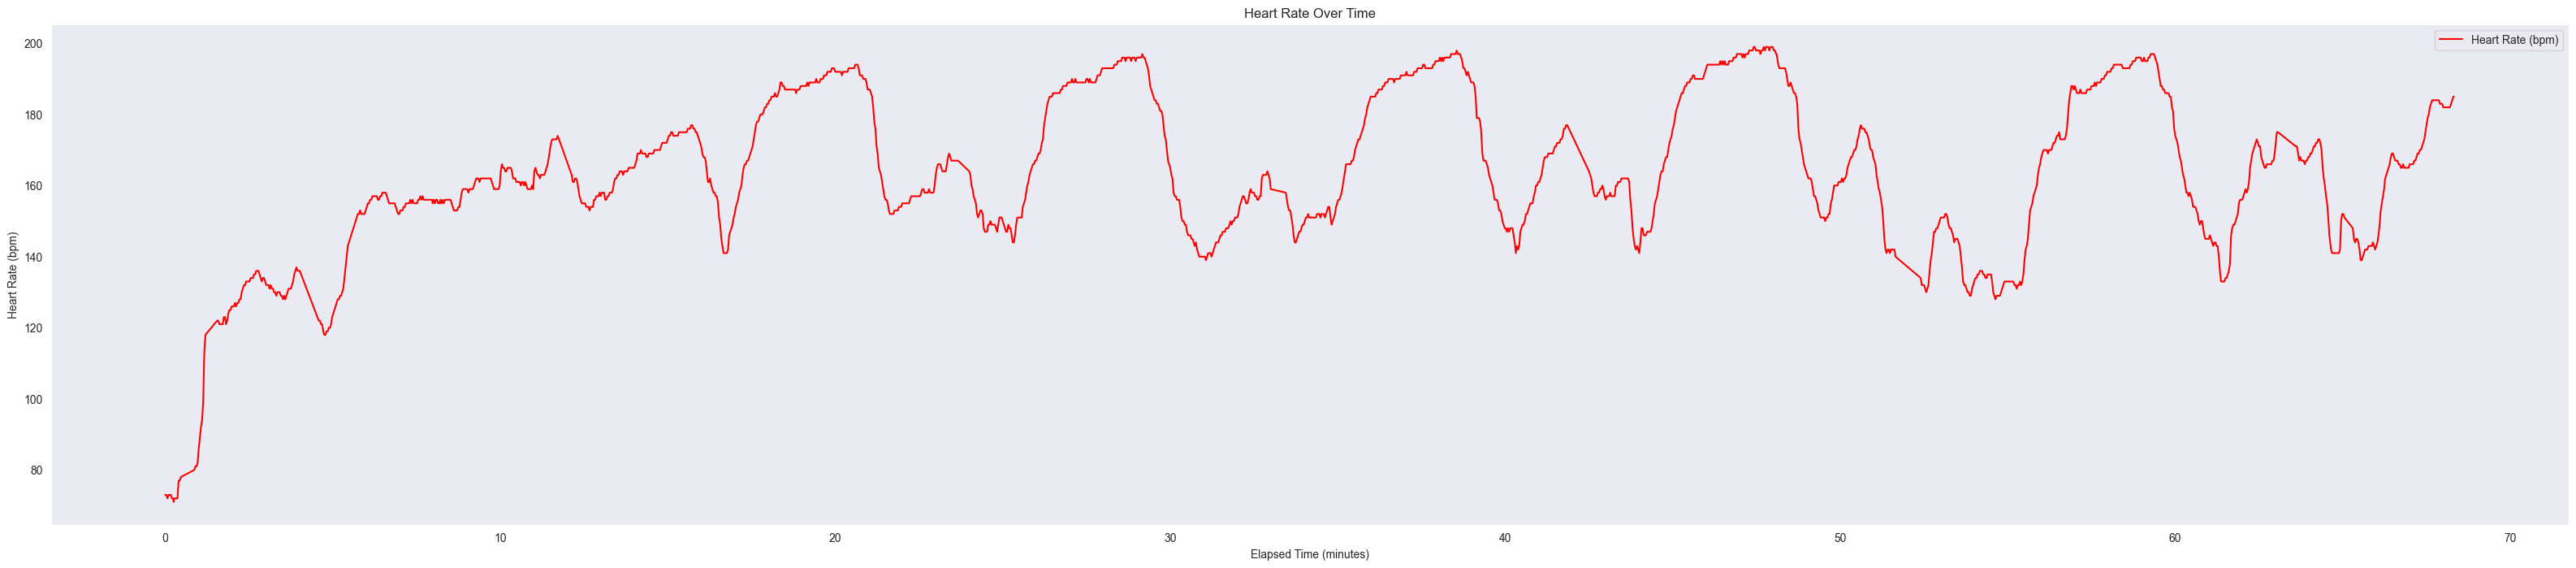

<Figure size 640x480 with 0 Axes>

In [16]:
print("Checking heart rate data over time")
plt.figure(figsize=(40,8))
plt.plot(df['elapsed_seconds']/60, df['heart_rate'], label='Heart Rate (bpm)', color='red')
plt.xlabel('Elapsed Time (minutes)')
plt.ylabel('Heart Rate (bpm)')
plt.title('Heart Rate Over Time')
plt.legend()
plt.grid()
plt.show()
plt.tight_layout()

Lets look at the connection between speed, heart rate and elevation.

Checking speed, heart rate and elevation over time


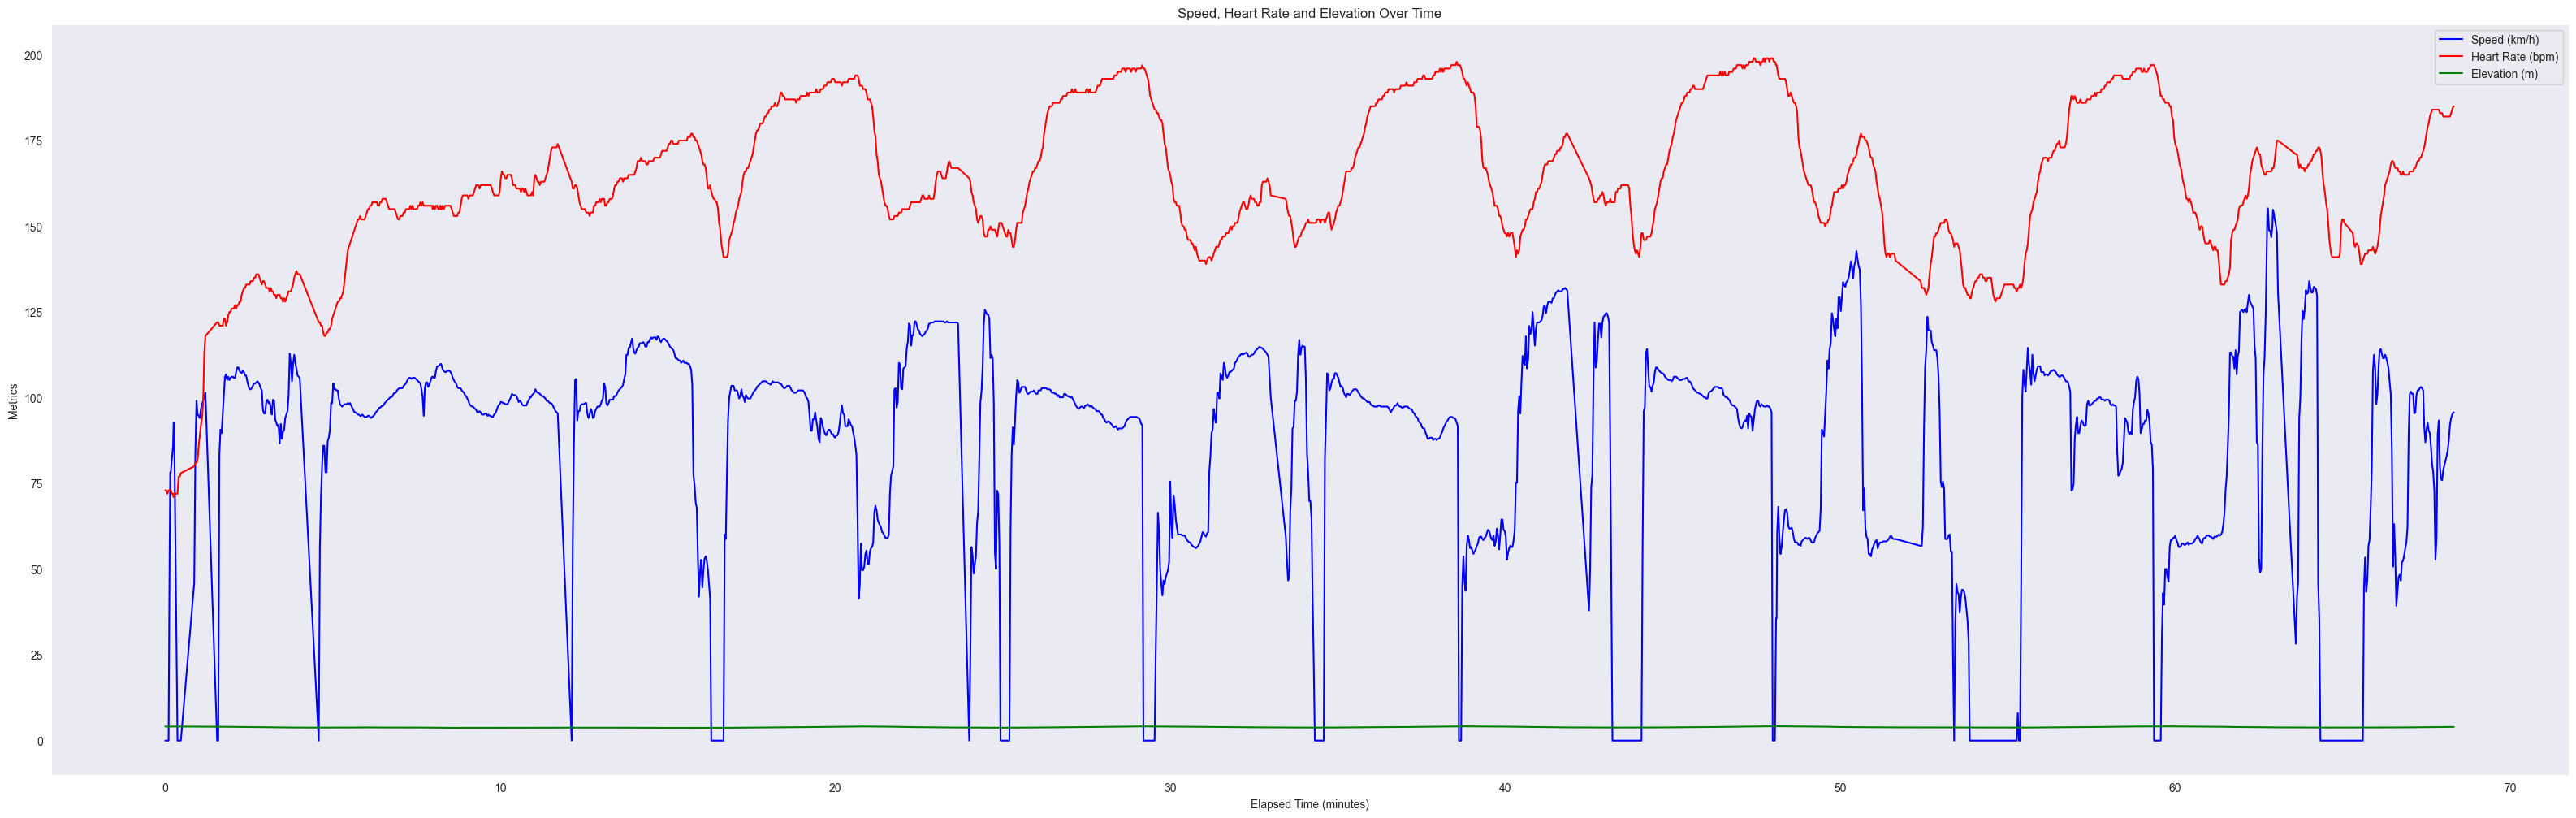

<Figure size 640x480 with 0 Axes>

In [22]:
print("Checking speed, heart rate and elevation over time")
plt.figure(figsize=(40,12))
plt.plot(df['elapsed_seconds']/60, df['speed_mps']*3.6, label='Speed (km/h)', color='blue')
plt.plot(df['elapsed_seconds']/60, df['heart_rate'], label='Heart Rate (bpm)', color='red')
plt.plot(df['elapsed_seconds']/60, df['elevation_m'], label='Elevation (m)', color='green')
plt.xlabel('Elapsed Time (minutes)')
plt.ylabel('Metrics')
plt.title('Speed, Heart Rate and Elevation Over Time')
plt.legend()
plt.grid()
plt.savefig('Speed_HR_Elev.pdf', bbox_inches='tight')
plt.show()
plt.tight_layout()

In [19]:
# Correlation analysis

Correlation matrix of key metrics


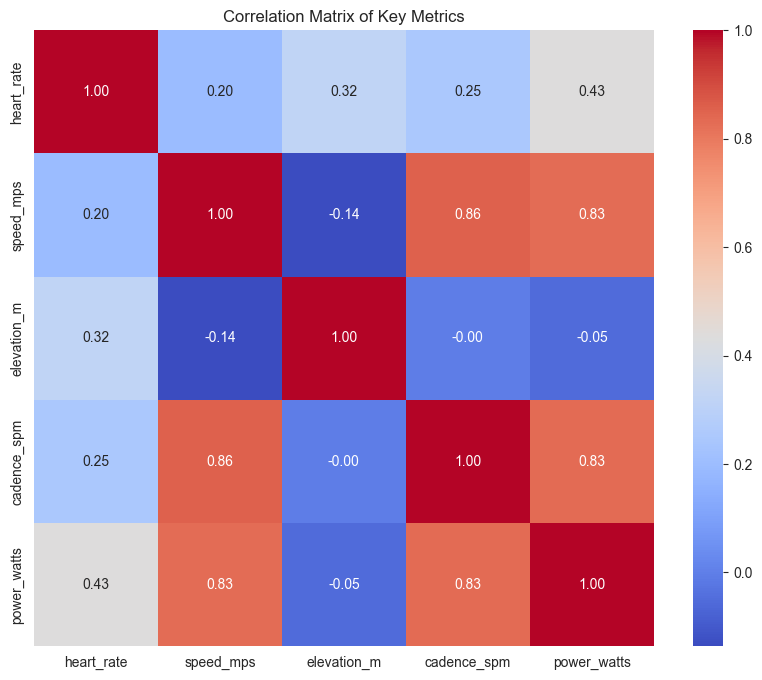

<Figure size 640x480 with 0 Axes>

In [21]:
print("Correlation matrix of key metrics")
key_metrics = df[['heart_rate', 'speed_mps', 'elevation_m', 'cadence_spm', 'power_watts']].dropna()
corr_matrix = key_metrics.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Key Metrics')
plt.savefig('Correlation_Matrix.pdf')
plt.show()
plt.tight_layout()

